#### 연령별 인구현황 피라미드
- 연령별 인구현황 검색해서 자료 수집

##### 판다스, 맵플롯립, 맵플롯립 한글 설정

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
## matplotlib 한글 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.size'] =  15
matplotlib.rcParams['axes.unicode_minus'] = False

- 파일 이름 설정

In [6]:
filename = '201601_201601_연령별인구현황_월간.xlsx'

- 남자 데이터 파일 읽어오기(skiprows, usecols, index_col)

In [11]:
df_m = pd.read_excel(filename , skiprows=3, usecols='b, e:y', index_col='행정기관')
df_m.head()

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,155,577","1,206,856","1,269,868","1,696,258","1,884,688","1,641,633","1,902,777","2,008,358","2,233,150","2,277,374",...,"2,031,839","1,424,146","1,058,511","799,513","567,225","291,133","104,773","31,627","7,069","3,832"
서울특별시,"200,437","200,281","214,007","292,742","354,609","367,513","427,894","407,957","429,079","420,928",...,"379,307","281,099","215,133","163,076","103,961","48,818","18,186","5,988","1,781","1,314"
부산광역시,"69,107","68,321","74,000","106,423","130,628","110,048","122,708","129,049","138,324","144,608",...,"154,315","120,314","88,623","64,233","41,545","19,081","6,255","1,733",370,322
대구광역시,"51,628","55,431","63,634","89,147","99,981","79,397","82,404","89,552","104,114","112,145",...,"99,263","70,412","50,774","36,848","25,794","13,261","4,182","1,090",219,120
인천광역시,"68,866","70,417","71,572","95,560","111,748","97,508","113,425","120,552","130,336","130,859",...,"119,223","74,874","52,847","37,063","24,389","12,470","4,668","1,588",386,194


In [12]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0~4세     18 non-null     object
 1   5~9세     18 non-null     object
 2   10~14세   18 non-null     object
 3   15~19세   18 non-null     object
 4   20~24세   18 non-null     object
 5   25~29세   18 non-null     object
 6   30~34세   18 non-null     object
 7   35~39세   18 non-null     object
 8   40~44세   18 non-null     object
 9   45~49세   18 non-null     object
 10  50~54세   18 non-null     object
 11  55~59세   18 non-null     object
 12  60~64세   18 non-null     object
 13  65~69세   18 non-null     object
 14  70~74세   18 non-null     object
 15  75~79세   18 non-null     object
 16  80~84세   18 non-null     object
 17  85~89세   18 non-null     object
 18  90~94세   18 non-null     object
 19  95~99세   18 non-null     object
 20  100세 이상  18 non-null     object
dtypes: object(21)
memory usage: 3.1+ KB


In [13]:
df_m.iloc[0]

0~4세       1,155,577
5~9세       1,206,856
10~14세     1,269,868
15~19세     1,696,258
20~24세     1,884,688
25~29세     1,641,633
30~34세     1,902,777
35~39세     2,008,358
40~44세     2,233,150
45~49세     2,277,374
50~54세     2,167,030
55~59세     2,031,839
60~64세     1,424,146
65~69세     1,058,511
70~74세       799,513
75~79세       567,225
80~84세       291,133
85~89세       104,773
90~94세        31,627
95~99세         7,069
100세 이상        3,832
Name: 전국  , dtype: object

- 전국 인구 (콤마), 제외하고 숫자로 변환

In [29]:
df_m = df_m.replace(',', '').astype(int)
df_m.iloc[0].info()
df_m

<class 'pandas.core.series.Series'>
Index: 21 entries, 0~4세 to 100세 이상
Series name: 전국  
Non-Null Count  Dtype
--------------  -----
21 non-null     int64
dtypes: int64(1)
memory usage: 892.0+ bytes


,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1155577,1206856,1269868,1696258,1884688,1641633,1902777,2008358,2233150,2277374,...,2031839,1424146,1058511,799513,567225,291133,104773,31627,7069,3832
서울특별시,200437,200281,214007,292742,354609,367513,427894,407957,429079,420928,...,379307,281099,215133,163076,103961,48818,18186,5988,1781,1314
부산광역시,69107,68321,74000,106423,130628,110048,122708,129049,138324,144608,...,154315,120314,88623,64233,41545,19081,6255,1733,370,322
대구광역시,51628,55431,63634,89147,99981,79397,82404,89552,104114,112145,...,99263,70412,50774,36848,25794,13261,4182,1090,219,120
인천광역시,68866,70417,71572,95560,111748,97508,113425,120552,130336,130859,...,119223,74874,52847,37063,24389,12470,4668,1588,386,194
광주광역시,34868,39140,43168,58806,59220,44364,53049,57583,64238,64513,...,50537,33690,27147,19914,12990,6599,2444,640,107,35
대전광역시,36201,38095,41072,54756,59993,51892,56390,58602,66116,67366,...,57342,38814,27470,19836,13308,6938,2560,764,187,65
울산광역시,30124,29911,30699,43305,48532,40540,46004,48671,50300,55749,...,48634,31593,20239,12531,7484,3477,1111,270,70,26
세종특별자치시,7721,7910,6546,5720,6110,5896,8874,10984,11595,9013,...,6469,4590,3282,2472,1941,1082,419,119,13,9


In [23]:
df_m.iloc[0]

0~4세       1155577
5~9세       1206856
10~14세     1269868
15~19세     1696258
20~24세     1884688
25~29세     1641633
30~34세     1902777
35~39세     2008358
40~44세     2233150
45~49세     2277374
50~54세     2167030
55~59세     2031839
60~64세     1424146
65~69세     1058511
70~74세      799513
75~79세      567225
80~84세      291133
85~89세      104773
90~94세       31627
95~99세        7069
100세 이상       3832
Name: 전국  , dtype: int64

In [30]:
df_m.head(3)

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1155577,1206856,1269868,1696258,1884688,1641633,1902777,2008358,2233150,2277374,...,2031839,1424146,1058511,799513,567225,291133,104773,31627,7069,3832
서울특별시,200437,200281,214007,292742,354609,367513,427894,407957,429079,420928,...,379307,281099,215133,163076,103961,48818,18186,5988,1781,1314
부산광역시,69107,68321,74000,106423,130628,110048,122708,129049,138324,144608,...,154315,120314,88623,64233,41545,19081,6255,1733,370,322


- 여자 데이터 파일 읽어오기

In [26]:
df_f = pd.read_excel(filename, skiprows=3, usecols='b, ab:av', index_col='행정기관', thousands=',')
df_f.info()
df_f

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   0~4세.1     18 non-null     int64
 1   5~9세.1     18 non-null     int64
 2   10~14세.1   18 non-null     int64
 3   15~19세.1   18 non-null     int64
 4   20~24세.1   18 non-null     int64
 5   25~29세.1   18 non-null     int64
 6   30~34세.1   18 non-null     int64
 7   35~39세.1   18 non-null     int64
 8   40~44세.1   18 non-null     int64
 9   45~49세.1   18 non-null     int64
 10  50~54세.1   18 non-null     int64
 11  55~59세.1   18 non-null     int64
 12  60~64세.1   18 non-null     int64
 13  65~69세.1   18 non-null     int64
 14  70~74세.1   18 non-null     int64
 15  75~79세.1   18 non-null     int64
 16  80~84세.1   18 non-null     int64
 17  85~89세.1   18 non-null     int64
 18  90~94세.1   18 non-null     int64
 19  95~99세.1   18 non-null     int64
 20  100세 이상.1  18 non-null     int64
dtypes: int64(21)


,0~4세.1,5~9세.1,10~14세.1,15~19세.1,20~24세.1,25~29세.1,30~34세.1,35~39세.1,40~44세.1,45~49세.1,...,55~59세.1,60~64세.1,65~69세.1,70~74세.1,75~79세.1,80~84세.1,85~89세.1,90~94세.1,95~99세.1,100세 이상.1
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1097056,1135460,1173465,1550918,1669493,1501433,1810248,1932966,2152314,2207501,...,2031127,1481190,1149146,983169,824732,554416,285345,103656,24808,12550
서울특별시,190626,189969,200408,272485,348361,376047,424773,404376,427085,425947,...,409171,308243,240138,183638,132504,82714,44692,17357,4820,3770
부산광역시,65250,64532,68320,94820,114039,101545,117395,123557,136822,148572,...,165289,129494,97584,75444,58405,36130,18377,6130,1381,1175
대구광역시,49154,51642,56820,78538,81748,65538,79689,89970,107450,114976,...,102553,76918,57700,47426,38600,24841,11587,3875,895,432
인천광역시,65234,66854,67358,88537,101389,91371,107463,113787,124612,130989,...,115277,75050,55356,44406,36357,24666,13339,4888,1169,523
광주광역시,32645,36664,39832,54354,53345,42032,51762,57971,65116,64647,...,53051,36656,30635,24449,19202,12653,6890,2485,651,282
대전광역시,34209,35981,37956,50148,53391,45497,54243,58795,66198,67619,...,58198,40056,29097,23945,19039,13074,6678,2455,540,225
울산광역시,28455,27633,27235,38021,37657,31841,41334,44452,50207,55663,...,46109,30276,19321,14333,11419,7642,3946,1459,278,116
세종특별자치시,7220,7709,6407,5374,5512,5969,9736,11227,10354,7494,...,6139,4568,3516,3168,2828,2130,1137,426,80,29


- 남자 데이터와 여자 데이터 컬럼명 일치시키기

In [31]:
df_m.columns

Index(['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세',
       '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세',
       '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상'],
      dtype='object')

In [32]:
df_f.columns

Index(['0~4세.1', '5~9세.1', '10~14세.1', '15~19세.1', '20~24세.1', '25~29세.1',
       '30~34세.1', '35~39세.1', '40~44세.1', '45~49세.1', '50~54세.1', '55~59세.1',
       '60~64세.1', '65~69세.1', '70~74세.1', '75~79세.1', '80~84세.1', '85~89세.1',
       '90~94세.1', '95~99세.1', '100세 이상.1'],
      dtype='object')

In [33]:
df_f.columns = df_m.columns

In [34]:
df_f.columns

Index(['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세',
       '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세',
       '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상'],
      dtype='object')

In [35]:
df_f.head(3)

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1097056,1135460,1173465,1550918,1669493,1501433,1810248,1932966,2152314,2207501,...,2031127,1481190,1149146,983169,824732,554416,285345,103656,24808,12550
서울특별시,190626,189969,200408,272485,348361,376047,424773,404376,427085,425947,...,409171,308243,240138,183638,132504,82714,44692,17357,4820,3770
부산광역시,65250,64532,68320,94820,114039,101545,117395,123557,136822,148572,...,165289,129494,97584,75444,58405,36130,18377,6130,1381,1175


- 전국 인구 (콤마), 제외하고 숫자로 변환

In [36]:
df_f = df_f.replace(',','').astype(int)

In [37]:
df_f.head(3)

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1097056,1135460,1173465,1550918,1669493,1501433,1810248,1932966,2152314,2207501,...,2031127,1481190,1149146,983169,824732,554416,285345,103656,24808,12550
서울특별시,190626,189969,200408,272485,348361,376047,424773,404376,427085,425947,...,409171,308243,240138,183638,132504,82714,44692,17357,4820,3770
부산광역시,65250,64532,68320,94820,114039,101545,117395,123557,136822,148572,...,165289,129494,97584,75444,58405,36130,18377,6130,1381,1175


In [38]:
df_f.iloc[0].info()

<class 'pandas.core.series.Series'>
Index: 21 entries, 0~4세 to 100세 이상
Series name: 전국  
Non-Null Count  Dtype
--------------  -----
21 non-null     int64
dtypes: int64(1)
memory usage: 892.0+ bytes


- 인구 피라미드 시각화, 크기( 15, 9 ), barh, 제목(2016년 인구 피라미드), png 파일 저장

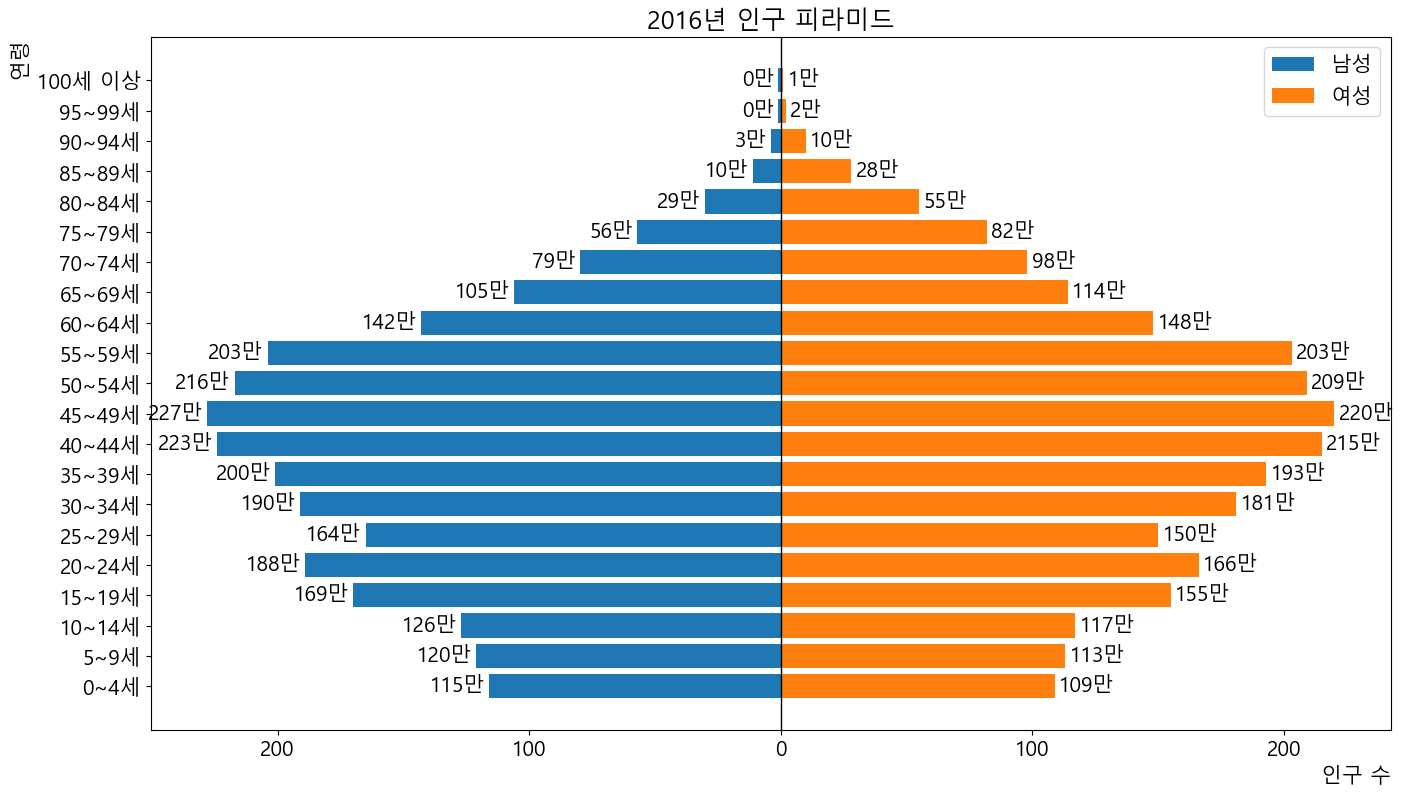

In [97]:
plt.figure(figsize=(16,9))

bars_m = plt.barh(df_m.columns, -df_m.iloc[0]//10000, label='남성')
bars_f = plt.barh(df_f.columns,  df_f.iloc[0]//10000, label='여성')

plt.bar_label(
    bars_m,
    labels=[f"{abs(x)//10000}만" for x in df_m.iloc[0]],
    padding=3
)

plt.bar_label(
    bars_f,
    labels=[f"{x//10000}만" for x in df_f.iloc[0]],
    padding=3
)
plt.axvline(0, color='black', linewidth=1)   # 가운데 기준선

# 🔥 x축 음수 안 보이게
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{abs(int(x))}")
)
plt.title('2016년 인구 피라미드')
plt.xlabel("인구 수", loc='right')
plt.ylabel('연령', loc='top')

plt.legend(loc='upper right')  # 🔥 이게 핵심
plt.savefig('2016년 인구 피라미드.png')
plt.show()

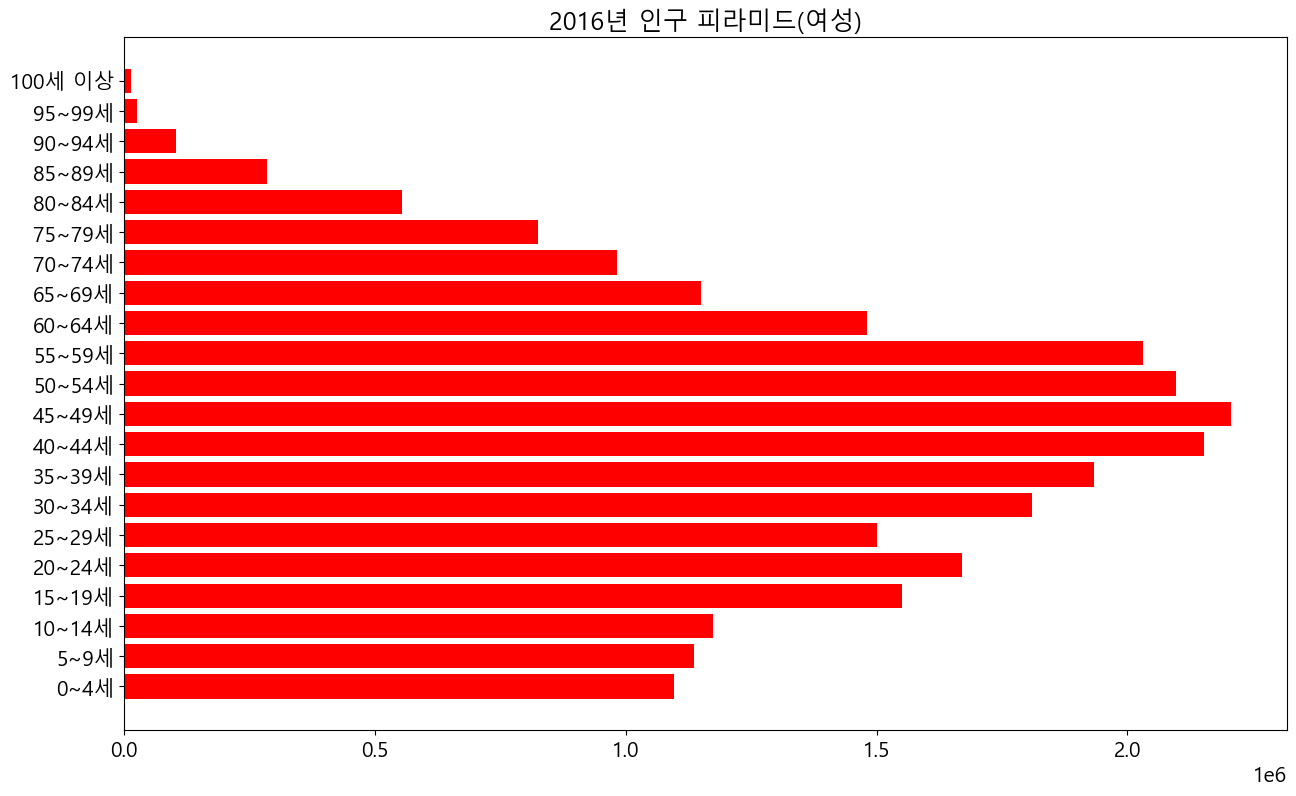

In [48]:
plt.figure(figsize=(15,9))
plt.barh(df_f.columns , df_f.iloc[0], color='red')
plt.title('2016년 인구 피라미드(여성)')
plt.savefig('2016년 인구 피라미드(여성).png', dpi=100)
plt.show()

- 2026년 인구 통계 분석

- 파일 이름 설정

In [53]:
filename2 = '202601_202601_연령별인구현황_월간.xlsx'

- 위에서 작업한 내용 종합해서 2026년 인구 피라미드 작성

In [55]:
df_m2 = pd.read_excel('202601_202601_연령별인구현황_월간.xlsx', usecols='a, b:v', index_col='행정기관', thousands=',')
df_m2.head(3)
df_m2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   0~4세     18 non-null     int64
 1   5~9세     18 non-null     int64
 2   10~14세   18 non-null     int64
 3   15~19세   18 non-null     int64
 4   20~24세   18 non-null     int64
 5   25~29세   18 non-null     int64
 6   30~34세   18 non-null     int64
 7   35~39세   18 non-null     int64
 8   40~44세   18 non-null     int64
 9   45~49세   18 non-null     int64
 10  50~54세   18 non-null     int64
 11  55~59세   18 non-null     int64
 12  60~64세   18 non-null     int64
 13  65~69세   18 non-null     int64
 14  70~74세   18 non-null     int64
 15  75~79세   18 non-null     int64
 16  80~84세   18 non-null     int64
 17  85~89세   18 non-null     int64
 18  90~94세   18 non-null     int64
 19  95~99세   18 non-null     int64
 20  100세 이상  18 non-null     int64
dtypes: int64(21)
memory usage: 3.1+ KB


In [56]:
df_m2.head(3)

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,642215,866644,1172541,1203042,1257595,1678453,1865447,1625836,1878781,1973028,...,2187358,2042291,1867600,1252675,854390,533952,266941,77376,12248,1451
서울특별시,103861,131995,177205,189262,227954,356221,404889,326530,337724,335866,...,356124,321753,302910,218245,156980,101983,48430,13652,2394,293
부산광역시,36014,50497,69210,66561,75681,95748,106268,94328,112469,120042,...,131571,127838,131273,97979,66807,40298,18408,4452,647,54


In [57]:
df_f2 = pd.read_excel('202601_202601_연령별인구현황_월간.xlsx', usecols='a, w:aq', index_col='행정기관', thousands=',')
df_f2.head(3)
df_f2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   0~4세.1     18 non-null     int64
 1   5~9세.1     18 non-null     int64
 2   10~14세.1   18 non-null     int64
 3   15~19세.1   18 non-null     int64
 4   20~24세.1   18 non-null     int64
 5   25~29세.1   18 non-null     int64
 6   30~34세.1   18 non-null     int64
 7   35~39세.1   18 non-null     int64
 8   40~44세.1   18 non-null     int64
 9   45~49세.1   18 non-null     int64
 10  50~54세.1   18 non-null     int64
 11  55~59세.1   18 non-null     int64
 12  60~64세.1   18 non-null     int64
 13  65~69세.1   18 non-null     int64
 14  70~74세.1   18 non-null     int64
 15  75~79세.1   18 non-null     int64
 16  80~84세.1   18 non-null     int64
 17  85~89세.1   18 non-null     int64
 18  90~94세.1   18 non-null     int64
 19  95~99세.1   18 non-null     int64
 20  100세 이상.1  18 non-null     int64
dtypes: int64(21)


In [58]:
df_f2.columns = df_m2.columns

In [59]:
df_f2.columns

Index(['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세',
       '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세',
       '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상'],
      dtype='object')

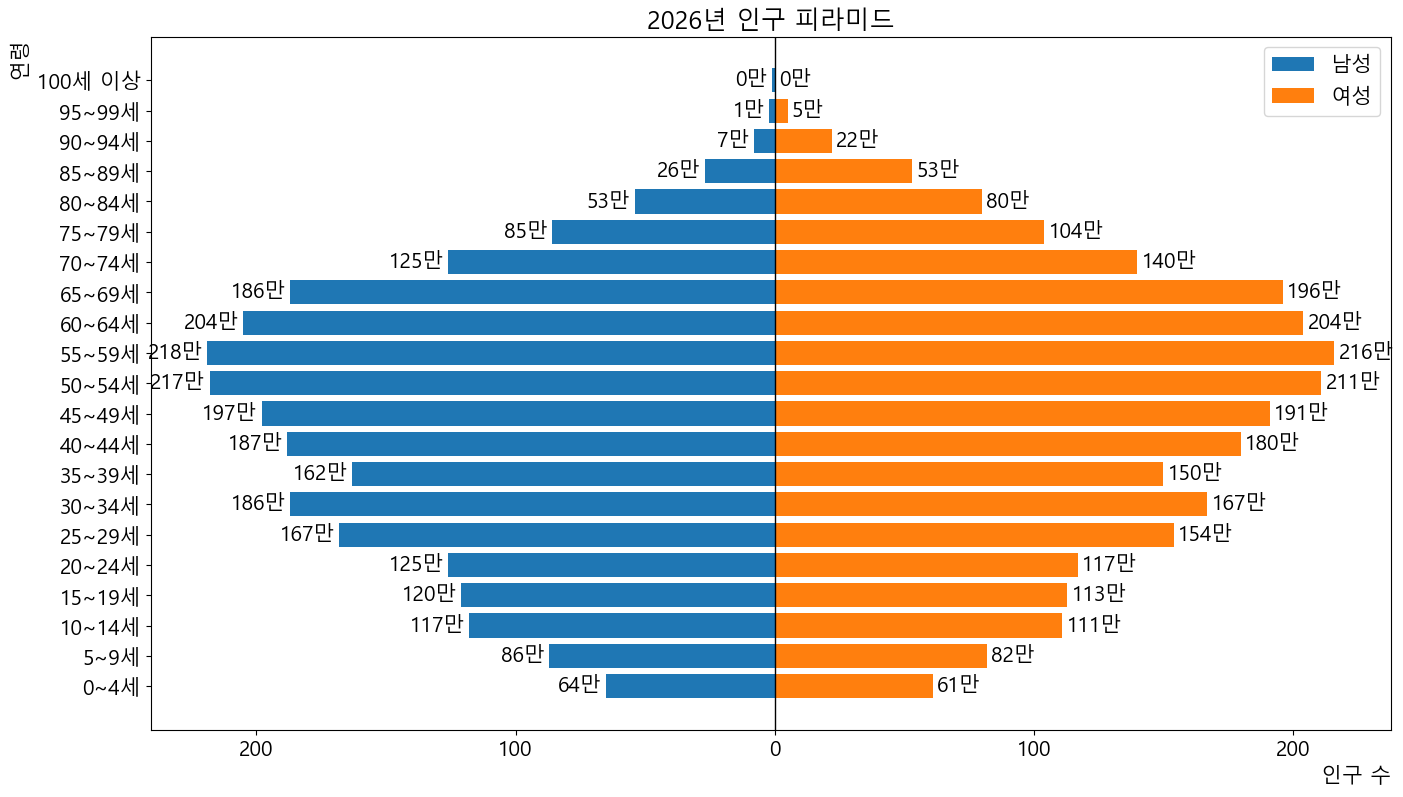

In [96]:
plt.figure(figsize=(16,9))

bars_m = plt.barh(df_m2.columns, -df_m2.iloc[0]//10000, label='남성')
bars_f = plt.barh(df_f2.columns,  df_f2.iloc[0]//10000, label='여성')

plt.bar_label(
    bars_m,
    labels=[f"{abs(x)//10000}만" for x in df_m2.iloc[0]],
    padding=3
)

plt.bar_label(
    bars_f,
    labels=[f"{x//10000}만" for x in df_f2.iloc[0]],
    padding=3
)
plt.axvline(0, color='black', linewidth=1)   # 가운데 기준선

# 🔥 x축 음수 안 보이게
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{abs(int(x))}")
)
plt.title('2026년 인구 피라미드')
plt.xlabel("인구 수", loc='right')
plt.ylabel('연령', loc='top')

plt.legend(loc='upper right')  # 🔥 이게 핵심
plt.savefig('2026년 인구 피라미드.png')
plt.show()

In [ ]:
plt.figure(figsize=(15,9))
plt.barh(df_m.columns , -df_m.iloc[0] // 1000)
plt.barh(df_m.columns , df_f.iloc[0] // 1000)
plt.title('2016년 인구 피라미드')
plt.savefig('2016년 인구 피라미드.png', dpi=100)
plt.show()